In [1]:
## Main modules 
using TDNEGF
using DifferentialEquations
using LinearAlgebra

println("Number of threads with JUlIA_NUM used in operations is : " , Threads.nthreads() )
println("Number of threads with BLAS used in operations is : " , BLAS.get_num_threads() )

Number of threads with JUlIA_NUM used in operations is : 1
Number of threads with BLAS used in operations is : 12


In [2]:
function init_params_blocks(;Nx::Int=6, Ny::Int=2, Nσ::Int=2, N_orb::Int=1,
                     γ::Float64=1.0, γso=0.5 + 0.0im,Nα = 2,
                     N_λ1::Int=49, N_λ2::Int=20, β::Float64=33.0)
                     
    # Main setup now uses the heterogeneous block-based auxiliary backend.
    Rλ, zλ = load_poles_square(N_λ1, N_λ2)
    p_model = ModelParamsTDNEGF(Nx = Nx, Ny = Ny, Nσ = Nσ, N_orb = N_orb,
                                Nα = Nα, N_λ1 = N_λ1, N_λ2 = N_λ2)

    H_ab    = build_H_ab(;Nx = p_model.Nx,Ny = p_model.Ny, Nσ = p_model.Nσ, N_orb = p_model.N_orb, γ = γ, γso = γso)
    Σᴸ_nλ   = build_Σᴸ_nλ(Rλ, zλ, p_model.Ny, p_model.Nσ, p_model.N_orb, p_model.N_λ1, p_model.N_λ2; β=β, γ=1.0)
    Σᴳ_nλ   = build_Σᴳ_nλ(Rλ, zλ, p_model.Ny, p_model.Nσ, p_model.N_orb, p_model.N_λ1, p_model.N_λ2; β=β, γ=1.0)
    χ_nλ    = build_χ_nλ(zλ, p_model.Ny, p_model.Nσ, p_model.N_orb, p_model.N_λ1, p_model.N_λ2; β=β, γ=1.0)
    ξ_anR   = build_ξ_an(p_model.Nx, p_model.Ny, p_model.Nσ, p_model.N_orb; xcol = p_model.Nx,y_coup = 1:p_model.Ny)
    ξ_anL   = build_ξ_an(p_model.Nx, p_model.Ny, p_model.Nσ, p_model.N_orb; xcol = 1,y_coup = 1:p_model.Ny)

    left_block  = SelfEnergyBlock(:left,  p_model.Nc, p_model.N_λ1, p_model.N_λ2, Σᴸ_nλ, Σᴳ_nλ, χ_nλ, ξ_anL)
    right_block = SelfEnergyBlock(:right, p_model.Nc, p_model.N_λ1, p_model.N_λ2, Σᴸ_nλ, Σᴳ_nλ, χ_nλ, ξ_anR)
    blocks = [left_block, right_block]

    p_model.H_ab  .= H_ab
    p_model.H0_ab .= H_ab
    p_blocks = ExperimentalBlockRHSParams(p_model.H_ab, blocks, ComplexF64[0.5 + 0.0im, -0.5 + 0.0im], p_model)
    u0 = zeros(ComplexF64, p_blocks.dims_ρ_ab[1]^2 + p_blocks.aux_layout.total_size)

    return p_model, p_blocks, u0
end


init_params_blocks (generic function with 1 method)

In [3]:
# Time dependent pulse 
smooth_switch_on(t::Float64;ti=30.0) =t < 0.0 ? 0.0 : (t < ti ? sin((pi/2)*t/ti)^2 : 1) ;

In [4]:
#### Iterative evolution
function two_terminal_square_lattice_evolution(t_0::Float64, Δt::Float64 ,t_end::Float64)
    println("Join the Main function")
    p_model, p_blocks, u0 = init_params_blocks()
    V =0.5
    # Update dynamic bias shifts directly; structural blocks remain unchanged.
    p_blocks.Δ_blocks[1] = +V
    p_blocks.Δ_blocks[2] = -V

    prob = ODEProblem(eom_tdnegf_blocks!, u0, (t_0,t_end), p_blocks)
    intg = init(prob,Vern7(),dt = Δt, save_everystep=false,adaptive=true,dense=false, reltol=1e-6, abstol=1e-8)
    println("The integrator has been set")

    N_steps = Int(round((t_end - t_0)/Δt))
    obs = ObservablesTDNEGF(p_model; N_tmax=N_steps , N_leads = length(p_blocks.blocks))
    obs.t = collect(t_0:Δt:(t_end-Δt))
    @time for (i,t) in enumerate(t_0:Δt:(t_end-Δt))
        println("time: ", round(i*Δt,digits=2))
        obs.idx = i
        flush(stdout)
        DifferentialEquations.step!(intg, Δt, true)

        dv = pointer_blocks(intg.u, p_blocks.dims_ρ_ab, p_blocks.aux_layout)
        obs_n_i!(dv, p_model, obs)
        obs_σ_i!(dv, p_model, obs)
        obs_Ixα!(dv, p_blocks, obs)
    end

    return obs, intg.u
end


two_terminal_square_lattice_evolution (generic function with 1 method)

In [5]:
# ### Adaptative evolution 
# p          = init_params() 
# p.Δ_α     .= [0.5,-0.5] 
# prob = ODEProblem(eom_tdnegf!,p.u, (0.0,100.0), p )
# println("The integrator has been set")
# #init(prob,Vern7(),dt = Δt, save_everystep=false,adaptive=true,dense=false)
# @time sol = solve(prob,Vern7(),adaptive=true,dense=false,reltol=1e-6, abstol=1e-8) ;
#println("Solution was obtained")
#### Alocate the observables 
# obs = ObservablesTDNEGF(p; N_tmax=length(sol.t) , N_leads = p.Nα)
# for (it,ut) in enumerate(sol.u)
#     obs.idx = it
#     dv = TDNEGF.pointer(ut,p)
#     obs_n_i!(dv, p, obs)            ### Charge density
#     obs_σ_i!(dv, p, obs)            ### Spin density 
#     obs_Ixα!(p, obs)   ### Spin and charge current
# end
# obs.t = sol.t
# using JLD2
# @save "./two_terminal_square_lattice_observables.jl2" obs
# println("The results has been saved")
# @load "two_terminal_square_lattice_observables.jl2" obs

In [5]:
obs , uf =  two_terminal_square_lattice_evolution(0.0,0.1,100.0)

Join the Main function
The integrator has been set
time: 0.1
time: 0.2
time: 0.3
time: 0.4
time: 0.5
time: 0.6
time: 0.7
time: 0.8
time: 0.9
time: 1.0
time: 1.1
time: 1.2
time: 1.3
time: 1.4
time: 1.5
time: 1.6
time: 1.7
time: 1.8
time: 1.9
time: 2.0
time: 2.1
time: 2.2
time: 2.3
time: 2.4
time: 2.5
time: 2.6
time: 2.7
time: 2.8
time: 2.9
time: 3.0
time: 3.1
time: 3.2
time: 3.3
time: 3.4
time: 3.5
time: 3.6
time: 3.7
time: 3.8
time: 3.9
time: 4.0
time: 4.1
time: 4.2
time: 4.3
time: 4.4
time: 4.5
time: 4.6
time: 4.7
time: 4.8
time: 4.9
time: 5.0
time: 5.1
time: 5.2
time: 5.3
time: 5.4
time: 5.5
time: 5.6
time: 5.7
time: 5.8
time: 5.9
time: 6.0
time: 6.1
time: 6.2
time: 6.3
time: 6.4
time: 6.5
time: 6.6
time: 6.7
time: 6.8
time: 6.9
time: 7.0
time: 7.1
time: 7.2
time: 7.3
time: 7.4
time: 7.5
time: 7.6
time: 7.7
time: 7.8
time: 7.9
time: 8.0
time: 8.1
time: 8.2
time: 8.3
time: 8.4
time: 8.5
time: 8.6
time: 8.7
time: 8.8
time: 8.9
time: 9.0
time: 9.1
time: 9.2
time: 9.3
time: 9.4
time: 9.5

(ObservablesTDNEGF{Float64}([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9  …  99.0, 99.1, 99.2, 99.3, 99.4, 99.5, 99.6, 99.7, 99.8, 99.9], [0.009917424010194385 0.038695063746496776 … 1.002589306232038 1.0025893067709204; 0.009917424010194398 0.0386950637464968 … 1.002589306232038 1.0025893067709204; … ; 0.00990831939116762 0.03855338597393852 … 0.9974105452965021 0.9974105470274202; 0.009908319391167621 0.03855338597393852 … 0.997410545296502 0.9974105470274199], [0.00030044673265553954 -9.114647149905443e-11 -2.505559937131252e-7; -0.0003004467326555396 -9.114647149083954e-11 2.505559937131252e-7; … ; 0.0002996236155830536 2.285445322365127e-10 2.4945676604416767e-7; -0.00029962361558305355 2.2854453223622732e-10 -2.4945676604676975e-7;;; 0.0023137358358488 -1.1490155307249617e-8 -7.73419504705719e-6; -0.0023137358358487994 -1.1490155306645303e-8 7.73419504705719e-6; … ; 0.002288354863044262 2.856937539016279e-8 7.59754203282989e-6; -0.0022883548630442617 2.8569375390542513e-8 -7

## Figures

In [6]:
using Plots, LaTeXStrings
gr()
default(linewidth = 2, framestyle = :box, grid = false,
        tickfontsize = 11, guidefontsize = 14, legendfontsize = 10,
        size = (650, 450), margin = 5Plots.mm)

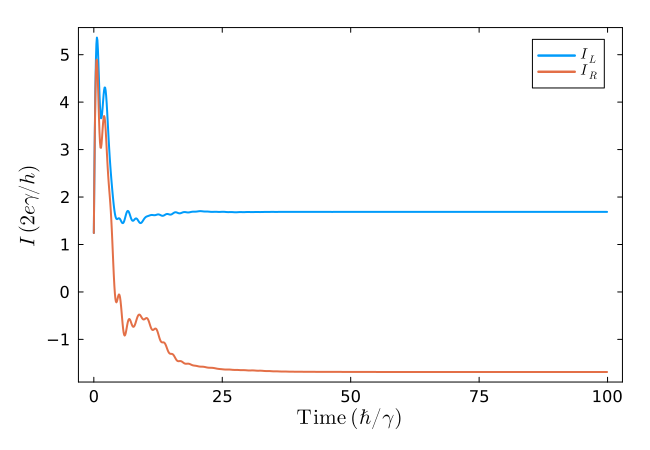

In [7]:
plot(obs.t, obs.Iα[1,:] .* π, label = L"I_L")
plot!(obs.t, obs.Iα[2,:] .* π, label = L"I_R")
plot!(xlabel = L"\mathrm{Time}\ (\hbar/\gamma)",
      ylabel = L"I\ (2e\gamma/h)",
      legend = :topright)

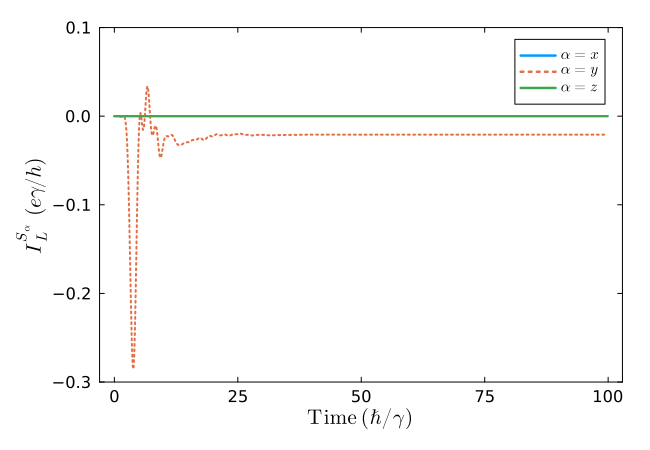

In [12]:
plot(obs.t, obs.Iαx[1,1,:], label = L"\alpha = x")
plot!(obs.t, obs.Iαx[1,2,:], label = L"\alpha = y", ls = :dot)
plot!(obs.t, obs.Iαx[1,3,:], label = L"\alpha = z")
plot!(xlabel = L"\mathrm{Time}\ (\hbar/\gamma)",
      ylabel = L"I^{S_\alpha}_L\ (e\gamma/h)",
      ylims = (-0.3, 0.1), legend = :topright)

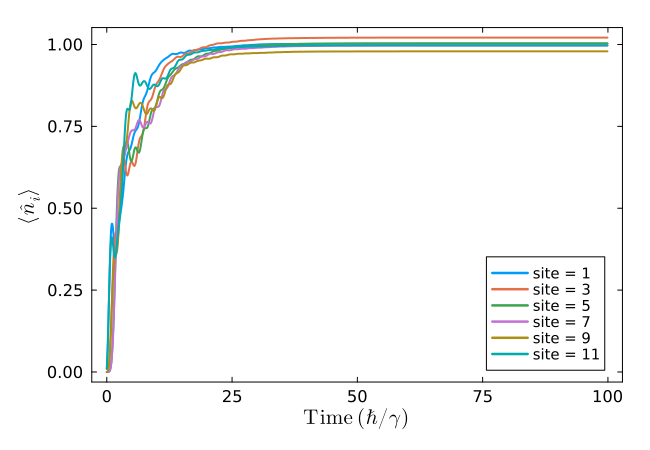

In [9]:
p = plot()
for site in 1:2:12
    plot!(p, obs.t, obs.n_i[site,:], label = "site = $site")
end
plot!(p, xlabel = L"\mathrm{Time}\ (\hbar/\gamma)",
      ylabel = L"\langle \hat{n}_i \rangle", legend = :bottomright)

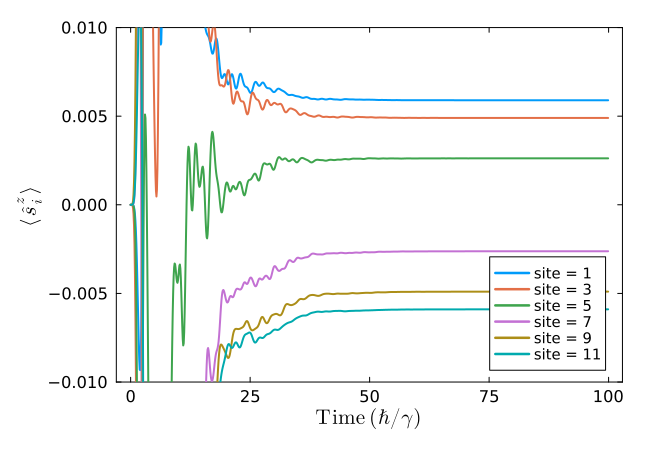

In [21]:
p = plot()
for site in 1:2:12
    plot!(p, obs.t, obs.σx_i[site,2,:], label = "site = $site")
end
plot!(p, xlabel = L"\mathrm{Time}\ (\hbar/\gamma)",
      ylabel = L"\langle \hat{s}^z_i \rangle",
      ylims = (-1e-2,1e-2), legend = :bottomright)

In [19]:
# En estacionario la corriente debe conservarse: I_L ≈ -I_R
i_ss = length(obs.t) ÷ 2 : length(obs.t)
println("I_L (media, t>50) = ", sum(obs.Iα[1, i_ss]) / length(i_ss))
println("I_R (media, t>50) = ", sum(obs.Iα[2, i_ss]) / length(i_ss))
println("suma (debe ≈ 0)   = ", sum(obs.Iα[1, i_ss] .+ obs.Iα[2, i_ss]) / length(i_ss))

I_L (media, t>50) = 0.5370033816064788
I_R (media, t>50) = -0.536945938242667
suma (debe ≈ 0)   = 5.744336381180071e-5
